## Setup code

In [1]:
import os
import sys
from pathlib import Path

import pkg_resources

# Install dependencies
installed_packages = [pkg.key for pkg in pkg_resources.working_set]
if "transformer-lens" not in installed_packages:
    %pip install transformer_lens==2.14.1 einops eindex-callum jaxtyping git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python

# root = "/content"

# os.chdir(root)

/tmp/ipykernel_1444391/2930708288.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import functools
import sys
from pathlib import Path
from typing import Callable

import circuitsvis as cv
import einops
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F
from eindex import eindex
import plotly.express as px
from IPython.display import display
from jaxtyping import Float, Int
from torch import Tensor
from tqdm import tqdm
from transformer_lens import (
    ActivationCache,
    FactoredMatrix,
    HookedTransformer,
    HookedTransformerConfig,
    utils,
)
from transformer_lens.hook_points import HookPoint

device = t.device("cuda" if t.cuda.is_available() else "cpu")

t.set_grad_enabled(False)

/home/dontsov/interp/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def to_numpy(tensor):
    """
    Helper function to convert a tensor to a numpy array. Also works on lists, tuples, and numpy arrays.
    """
    if isinstance(tensor, np.ndarray):
        return tensor
    elif isinstance(tensor, (list, tuple)):
        array = np.array(tensor)
        return array
    elif isinstance(tensor, (t.Tensor, t.nn.parameter.Parameter)):
        return tensor.detach().cpu().numpy()
    elif isinstance(tensor, (int, float, bool, str)):
        return np.array(tensor)
    else:
        raise ValueError(f"Input to to_numpy has invalid type: {type(tensor)}")


update_layout_set = {
    "xaxis_range",
    "yaxis_range",
    "hovermode",
    "xaxis_title",
    "yaxis_title",
    "colorbar",
    "colorscale",
    "coloraxis",
    "title_x",
    "bargap",
    "bargroupgap",
    "xaxis_tickformat",
    "yaxis_tickformat",
    "title_y",
    "legend_title_text",
    "xaxis_showgrid",
    "xaxis_gridwidth",
    "xaxis_gridcolor",
    "yaxis_showgrid",
    "yaxis_gridwidth",
    "yaxis_gridcolor",
    "showlegend",
    "xaxis_tickmode",
    "yaxis_tickmode",
    "margin",
    "xaxis_visible",
    "yaxis_visible",
    "bargap",
    "bargroupgap",
    "coloraxis_showscale",
    "xaxis_tickangle",
    "yaxis_scaleanchor",
    "xaxis_tickfont",
    "yaxis_tickfont",
}

update_traces_set = {"textposition"}


def reorder_list_in_plotly_way(L: list, col_wrap: int):
    """
    Helper function, because Plotly orders figures in an annoying way when there's column wrap.
    """
    L_new = []
    while len(L) > 0:
        L_new.extend(L[-col_wrap:])
        L = L[:-col_wrap]
    return L_new


def imshow(tensor: t.Tensor, renderer=None, **kwargs):
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in update_layout_set}
    if ("size" in kwargs_pre) or ("shape" in kwargs_pre):
        size = kwargs_pre.pop("size", None) or kwargs_pre.pop("shape", None)
        kwargs_pre["height"], kwargs_pre["width"] = size  # type: ignore
    facet_labels = kwargs_pre.pop("facet_labels", None)
    border = kwargs_pre.pop("border", False)
    return_fig = kwargs_pre.pop("return_fig", False)
    text = kwargs_pre.pop("text", None)
    xaxis_tickangle = kwargs_post.pop("xaxis_tickangle", None)
    # xaxis_tickfont = kwargs_post.pop("xaxis_tickangle", None)
    static = kwargs_pre.pop("static", False)
    if "color_continuous_scale" not in kwargs_pre:
        kwargs_pre["color_continuous_scale"] = "RdBu"
    if "color_continuous_midpoint" not in kwargs_pre:
        kwargs_pre["color_continuous_midpoint"] = 0.0
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    fig = px.imshow(to_numpy(tensor), **kwargs_pre).update_layout(**kwargs_post)
    if facet_labels:
        # Weird thing where facet col wrap means labels are in wrong order
        if "facet_col_wrap" in kwargs_pre:
            facet_labels = reorder_list_in_plotly_way(facet_labels, kwargs_pre["facet_col_wrap"])
        for i, label in enumerate(facet_labels):
            fig.layout.annotations[i]["text"] = label  # type: ignore
    if border:
        fig.update_xaxes(showline=True, linewidth=1, linecolor="black", mirror=True)
        fig.update_yaxes(showline=True, linewidth=1, linecolor="black", mirror=True)
    if text:
        if tensor.ndim == 2:
            # if 2D, then we assume text is a list of lists of strings
            assert isinstance(text[0], list)
            assert isinstance(text[0][0], str)
            text = [text]
        else:
            # if 3D, then text is either repeated for each facet, or different
            assert isinstance(text[0], list)
            if isinstance(text[0][0], str):
                text = [text for _ in range(len(fig.data))]
        for i, _text in enumerate(text):
            fig.data[i].update(text=_text, texttemplate="%{text}", textfont={"size": 12})
    # Very hacky way of fixing the fact that updating layout with xaxis_* only applies to first facet by default
    if xaxis_tickangle is not None:
        n_facets = 1 if tensor.ndim == 2 else tensor.shape[0]
        for i in range(1, 1 + n_facets):
            xaxis_name = "xaxis" if i == 1 else f"xaxis{i}"
            fig.layout[xaxis_name]["tickangle"] = xaxis_tickangle  # type: ignore
    return fig if return_fig else fig.show(renderer=renderer, config={"staticPlot": static})

# Transformer Architecture

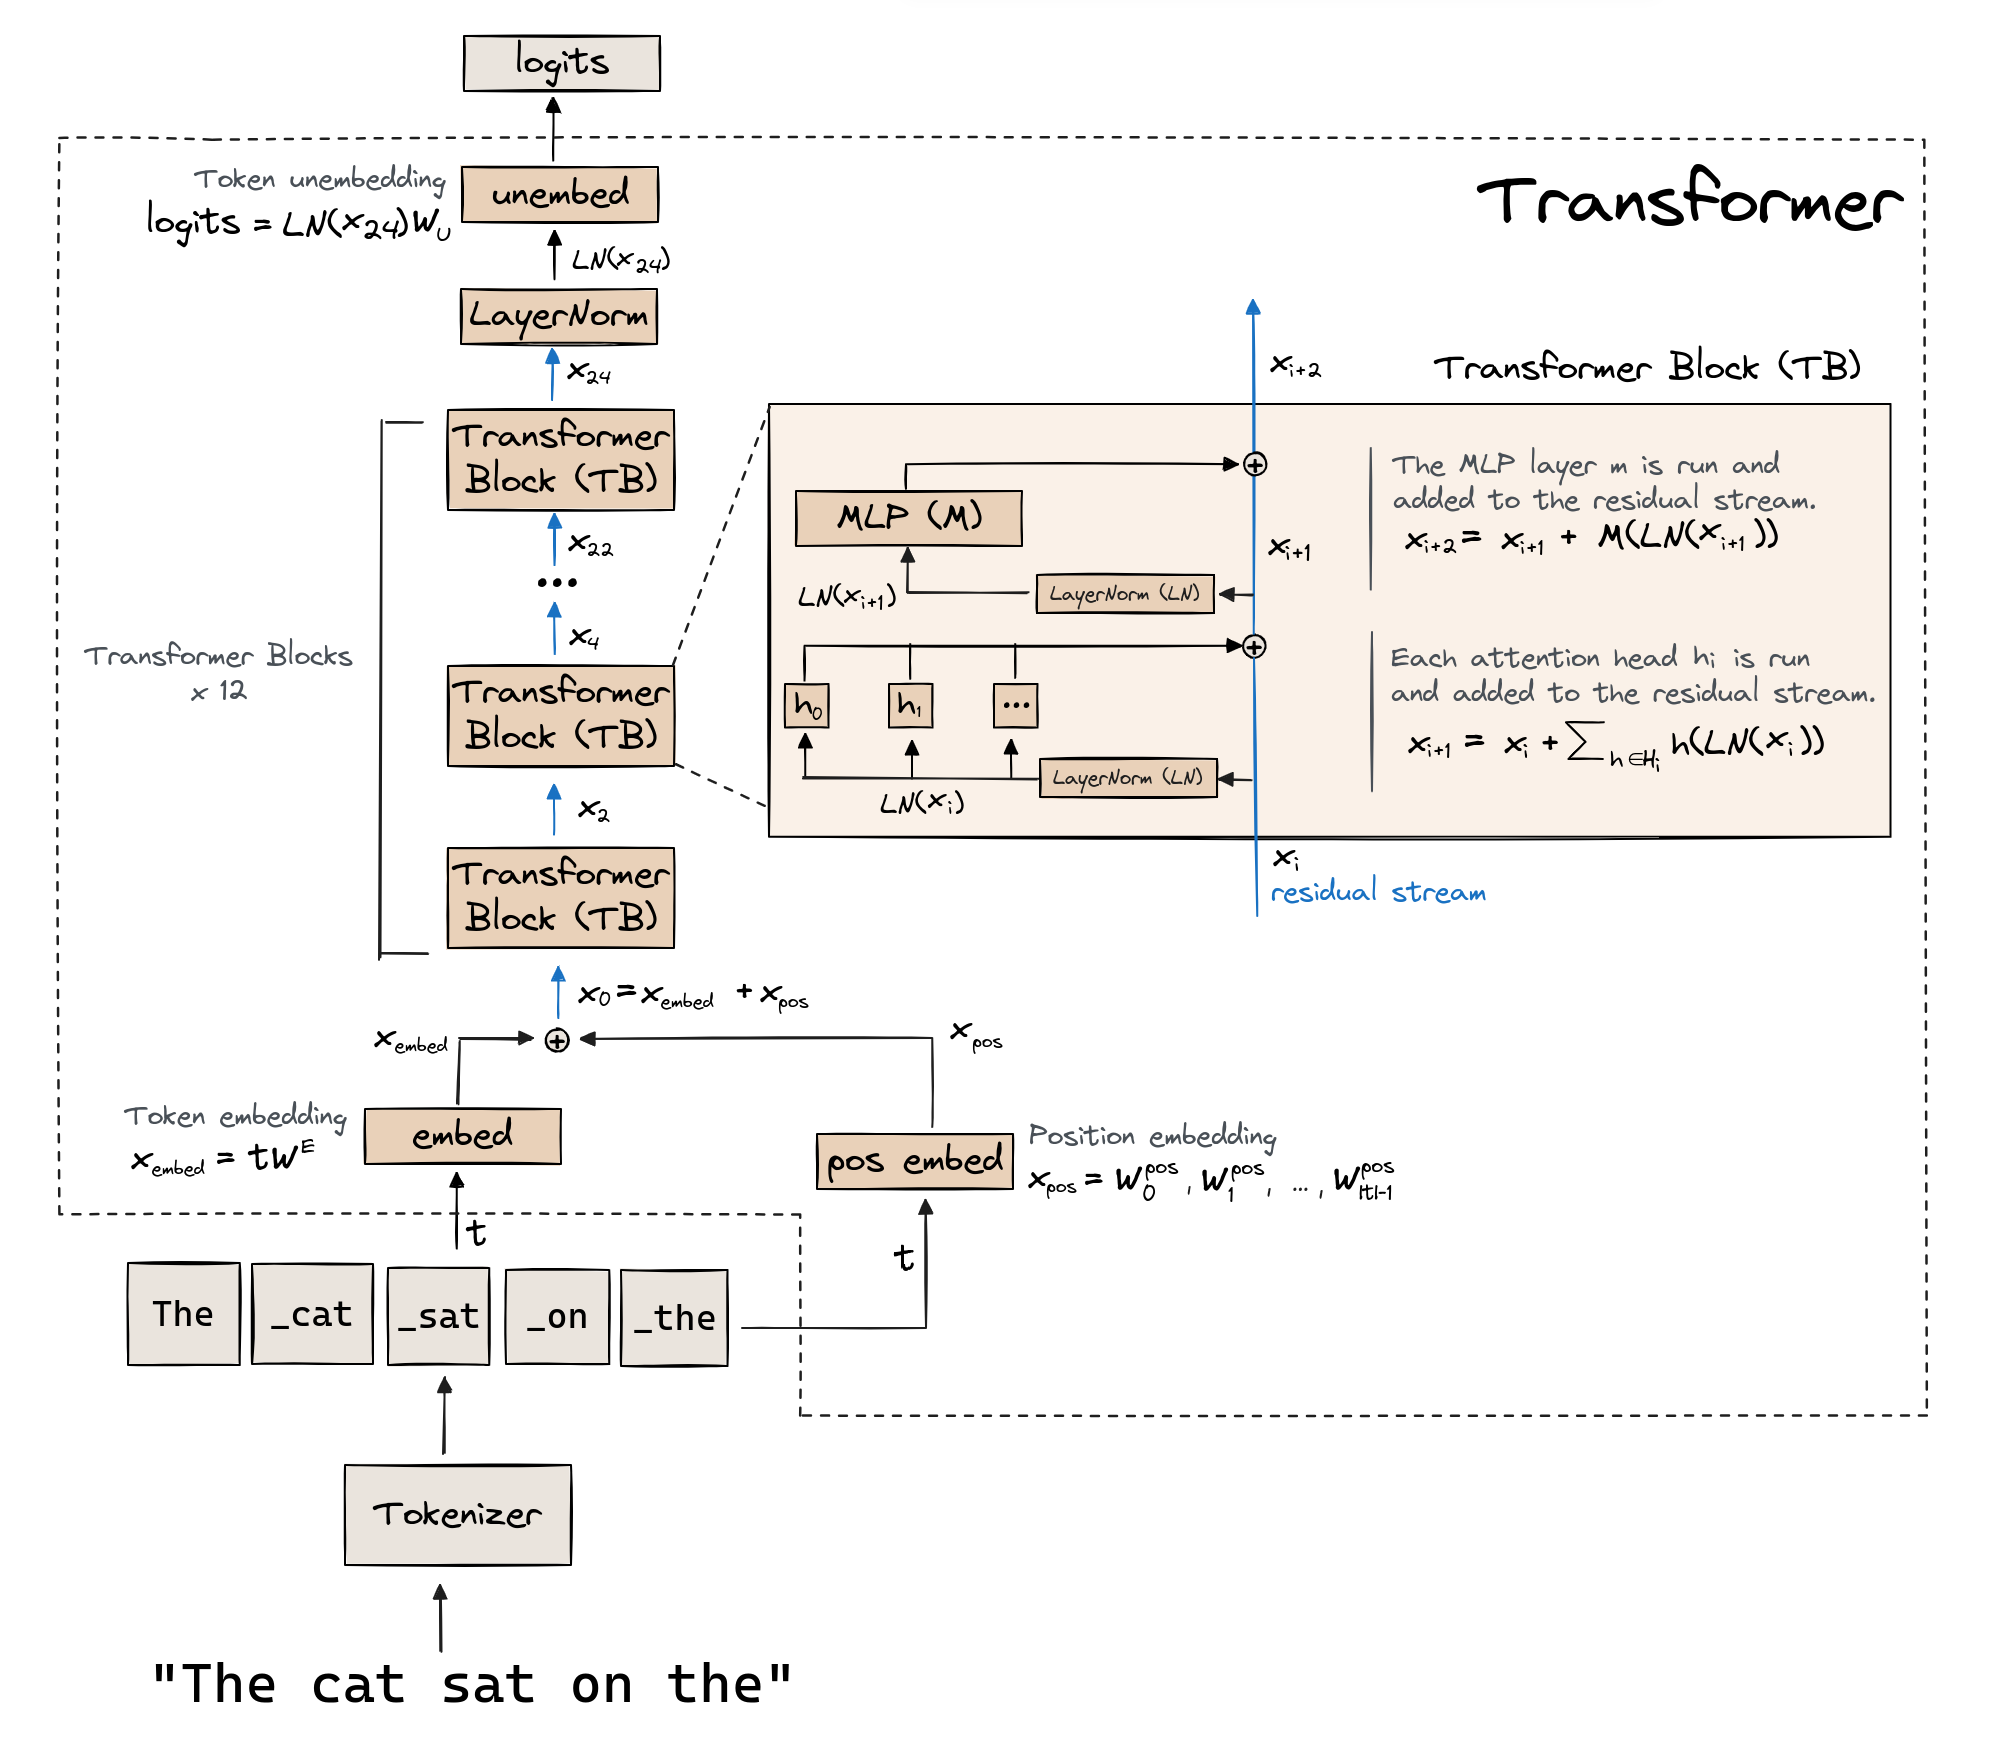

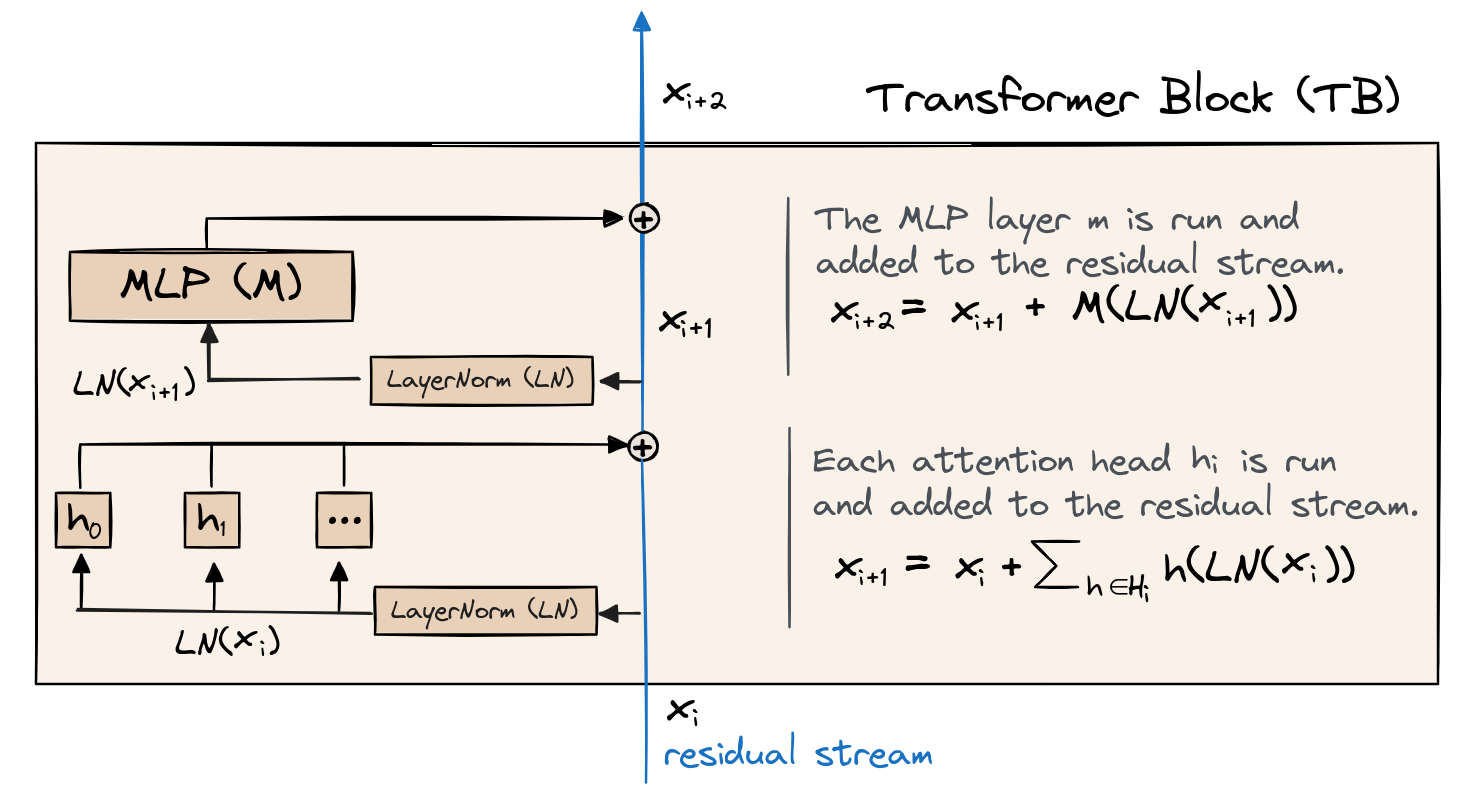

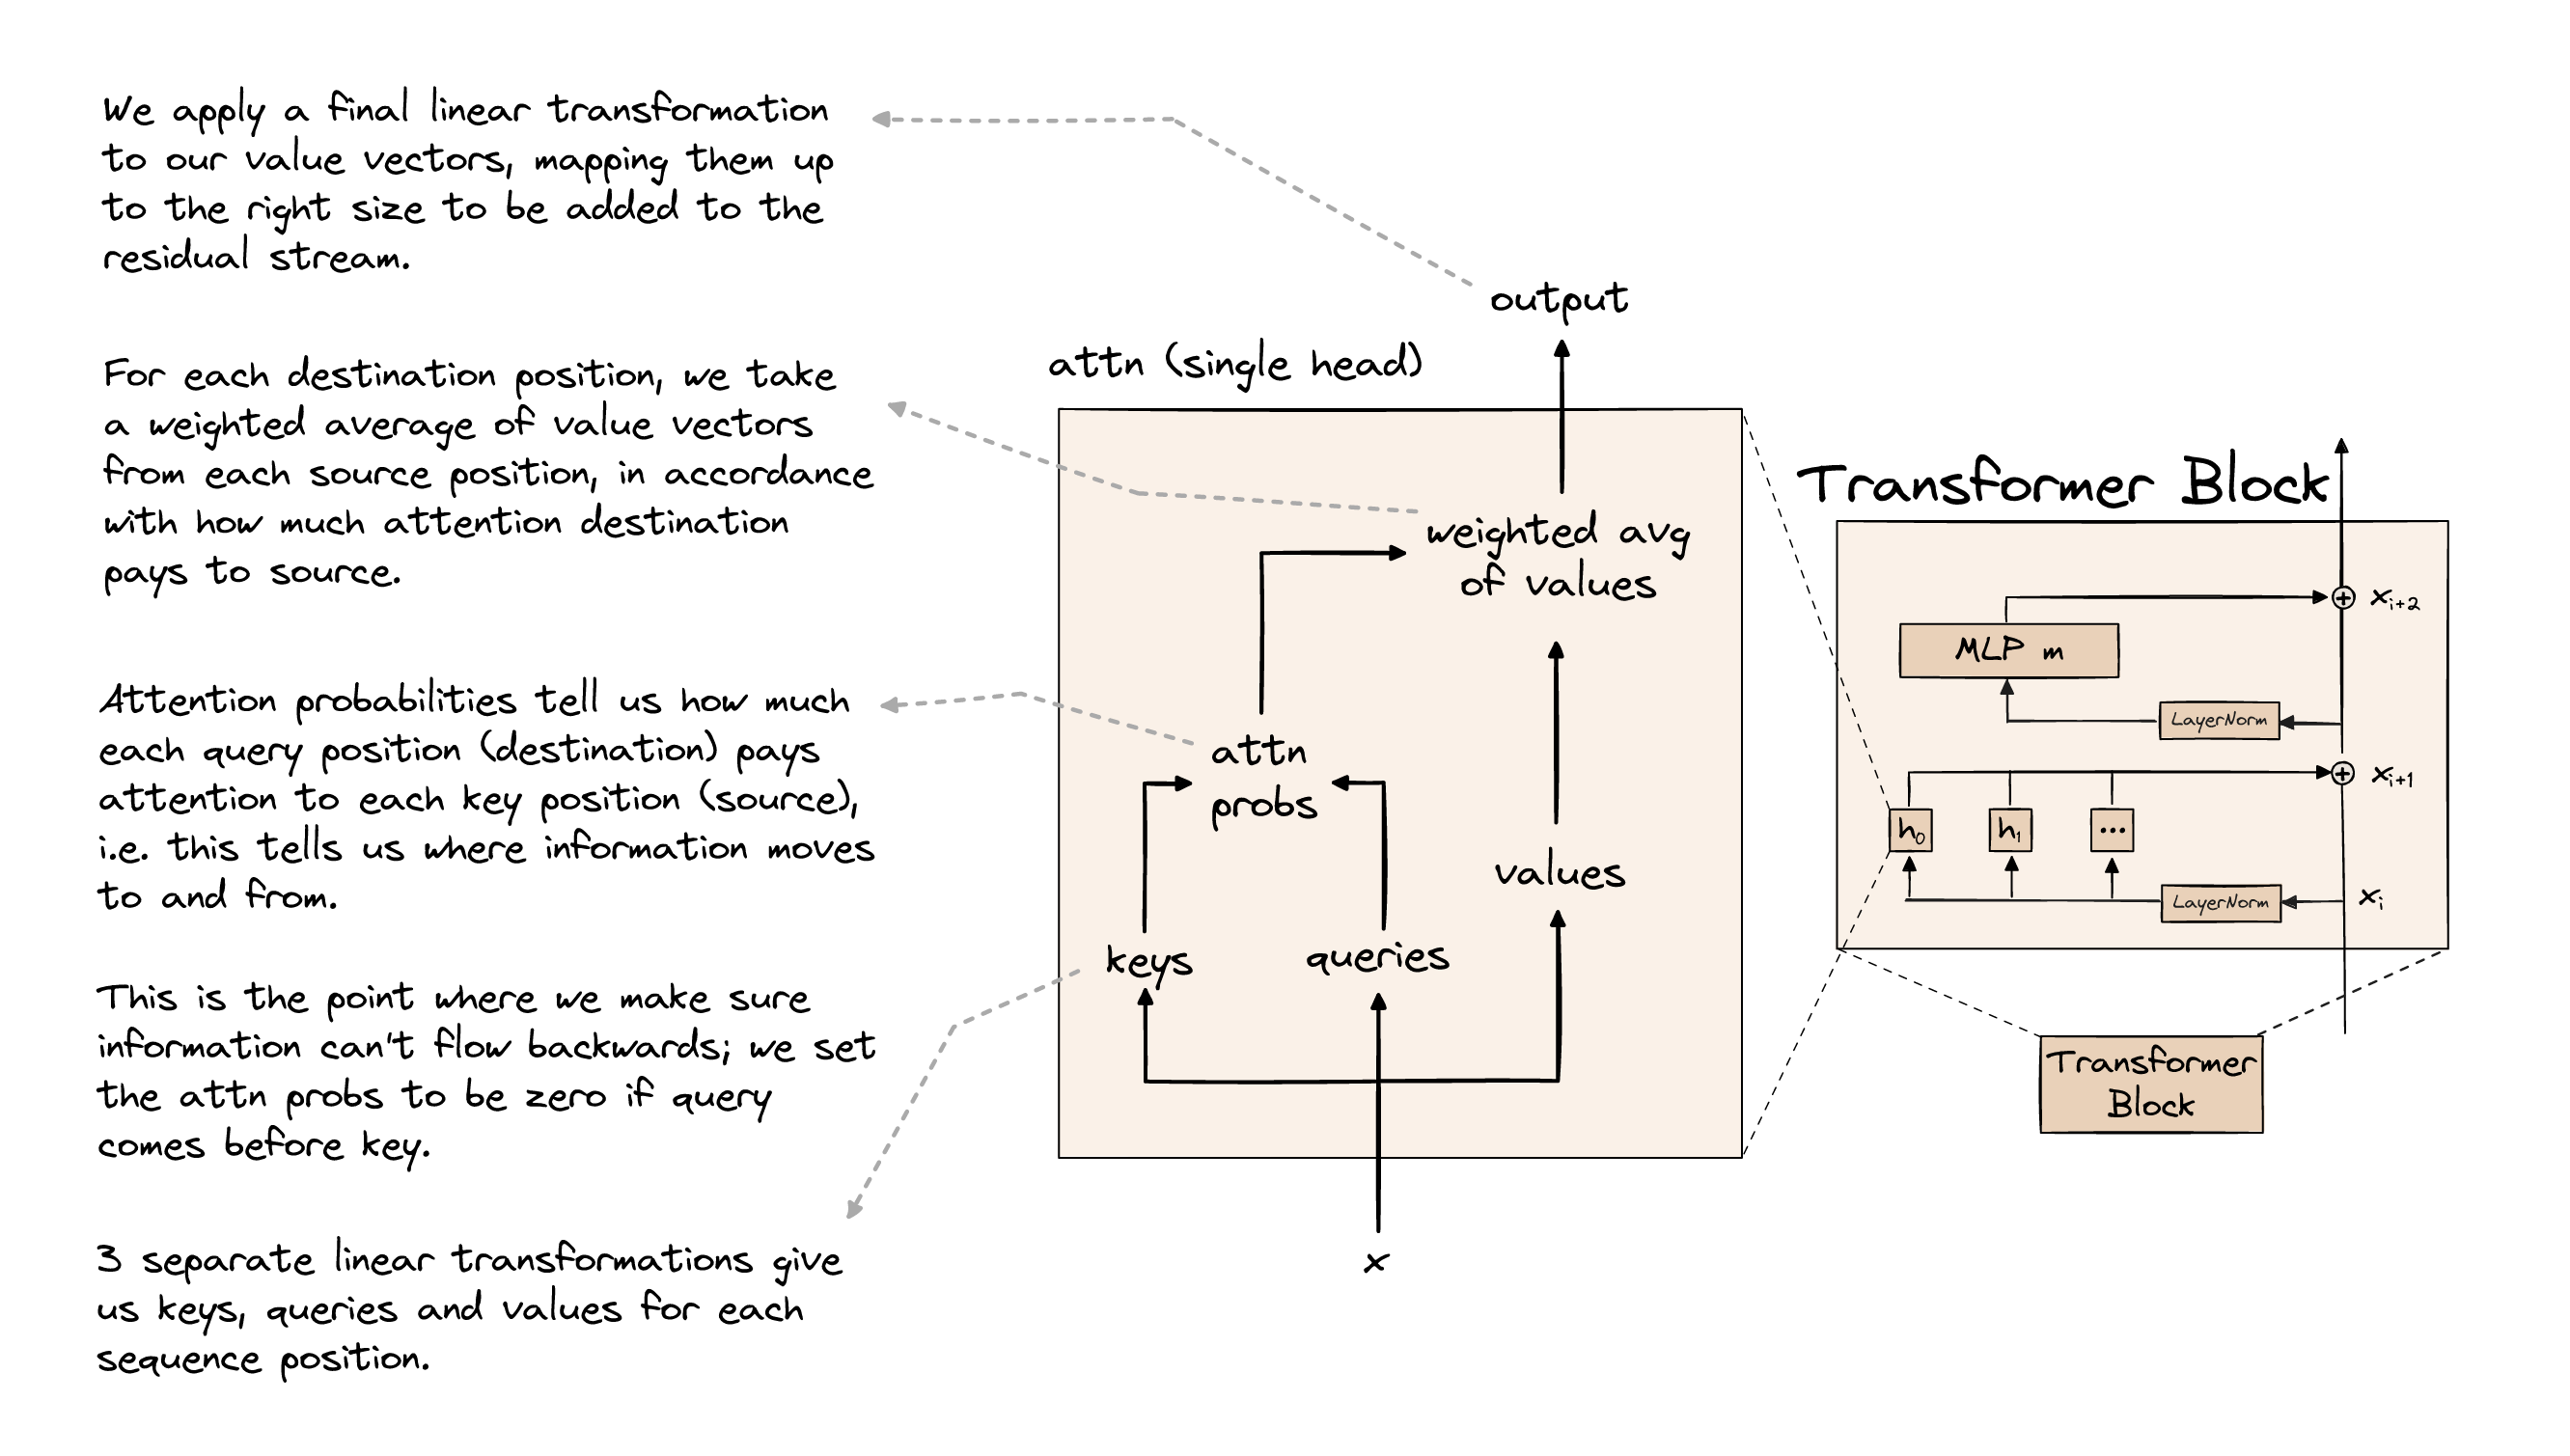

# 1️⃣ TransformerLens: Introduction

This section is a quick introduction to the [TransformerLens](https://github.com/TransformerLensOrg/TransformerLens?ysclid=m7al57nk6207670258) library.

> ##### Learning Objectives
>
> - Load and run a `HookedTransformer` model
> - Understand the basic architecture of these models
> - Use the model's tokenizer to convert text to tokens, and vice versa
> - Know how to cache activations, and to access activations from the cache

## Loading and Running Models

TransformerLens comes loaded with most of the current SoTA GPT-style models. You can load any of them in with `HookedTransformer.from_pretrained(MODEL_NAME)`. Here, we will inspect the GPT-2 small model consisting of 80M parameters in total.

In [54]:
gpt2_small: HookedTransformer = HookedTransformer.from_pretrained("gpt2-small")

Loaded pretrained model gpt2-small into HookedTransformer


### HookedTransformerConfig

Alternatively, you can define a config object, then call `HookedTransformer.from_config(cfg)` to define your model. This is particularly useful when you want to have finer control over the architecture of your model.

Regarding of the loading way, you can access the configuration through the `cfg` attribute of the model instance.

Use `gpt2_small.cfg` to find the following, for your GPT-2 Small model:

* Number of layers
* Number of heads per layer
* Maximum context window

In [111]:
gpt2_small.cfg

HookedTransformerConfig:
{'NTK_by_parts_factor': 8.0,
 'NTK_by_parts_high_freq_factor': 4.0,
 'NTK_by_parts_low_freq_factor': 1.0,
 'NTK_original_ctx_len': 8192,
 'act_fn': 'gelu_new',
 'attention_dir': 'causal',
 'attn_only': False,
 'attn_scale': 8.0,
 'attn_scores_soft_cap': -1.0,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 64,
 'd_mlp': 3072,
 'd_model': 768,
 'd_vocab': 50257,
 'd_vocab_out': 50257,
 'decoder_start_token_id': None,
 'default_prepend_bos': True,
 'device': device(type='cuda'),
 'dtype': torch.float32,
 'eps': 1e-05,
 'experts_per_token': None,
 'final_rms': False,
 'from_checkpoint': False,
 'gated_mlp': False,
 'init_mode': 'gpt2',
 'init_weights': False,
 'initializer_range': 0.02886751345948129,
 'load_in_4bit': False,
 'model_name': 'gpt2',
 'n_ctx': 1024,
 'n_devices': 1,
 'n_heads': 12,
 'n_key_value_heads': None,
 'n_layers': 12,
 'n_params': 84934656,
 'normalization_type': 'LNPre',
 

In [110]:
print(f"n_layers = {gpt2_small.cfg.n_layers}"
      f"\nn_heads = {gpt2_small.cfg.n_heads}"
      f"\nn_ctx = {gpt2_small.cfg.n_ctx}")

n_layers = 12
n_heads = 12
n_ctx = 1024


### Running your model

Models can be run on a single string or a tensor of tokens (shape: `[batch, position]`, all integers). The possible return types are:

* `"logits"` (shape `[batch, position, d_vocab]`, floats),
* `"loss"` (the cross-entropy loss when predicting the next token),
* `"both"` (a tuple of `(logits, loss)`)
* `None` (run the model, but don't calculate the logits - this is faster when we only want to use intermediate activations)

In [ ]:
example_text = """Hello! This is a seminar on Mechanistic Interpretability of GPT-style models loaded as a HookedTransformer instance. Now I will do `bla-bla-bla` a bit:

bla-bla-bla-bla-bla-bla-bla-bla-bla.

Let's find if our model instantiated using HookedTransformer works properly by computing the loss on this text.
"""

loss = gpt2_small(example_text, return_type="loss")
print("Model loss:", loss)

Model loss: tensor([[[  7.5261,  11.1214,   7.8919,  ...,  -3.1299,  -3.3873,   8.5934],
         [ 12.6877,   5.6732,   1.4202,  ...,  -0.1857,  -0.5829,   5.4394],
         [  7.7657,   4.7331,   5.1378,  ...,  -2.9349,  -2.7352,   9.6095],
         ...,
         [  9.1088,   5.4190,   3.7296,  ...,  -2.6634,  -1.7859,   7.0485],
         [  6.1211,   2.8830,   5.6932,  ...,  -2.4280,  -2.9112,  11.2731],
         [ 15.3128,  17.7804,  13.7209,  ...,  -7.2379, -13.0344,  17.6149]]],
       device='cuda:0')


### TransformerLens architecture


HookedTransformer adapts the GPT-style architectures to have the same layer structure and namespace, making it much easier to access model parameters and intermediate activations.

The most significant changes are to the internal structure of the attention heads:

* The weights `W_K`, `W_Q`, `W_V` mapping the residual stream to queries, keys and values are 3 separate matrices, rather than big concatenated one.
* The weight matrices `W_K`, `W_Q`, `W_V`, `W_O` and activations have separate `head_index` and `d_head` axes, rather than flattening them into one big axis.
    * The activations all have shape `[batch, position, head_index, d_head]`.
    * `W_K`, `W_Q`, `W_V` have shape `[head_index, d_model, d_head]` and `W_O` has shape `[head_index, d_head, d_model]`
* **Important - we generally follow the convention that weight matrices multiply on the right rather than the left.** In other words, they have shape `[input, output]`, and we have `new_activation = old_activation @ weights + bias`.
    * Click the dropdown below for examples of this, if it seems unintuitive.

<details>
<summary>Examples of matrix multiplication in our model</summary>

* **Query matrices**
    * Each query matrix `W_Q` for a particular layer and head has shape `[d_model, d_head]`.
    * So if a vector `x` in the residual stream has length `d_model`, then the corresponding query vector is `x @ W_Q`, which has length `d_head`.
* **Embedding matrix**
    * The embedding matrix `W_E` has shape `[d_vocab, d_model]`.
    * So if `A` is a one-hot-encoded vector of length `d_vocab` corresponding to a particular token, then the embedding vector for this token is `A @ W_E`, which has length `d_model`.

</details>

A few shortctus to make your lives easier when using these models:

* You can index weights like `W_Q` directly from the model via e.g. `model.blocks[0].attn.W_Q` (which gives you the `[nheads, d_model, d_head]` query weights for all heads in layer 0).
    * But an easier way is just to index with `model.W_Q`, which gives you the `[nlayers, nheads, d_model, d_head]` tensor containing **every** query weight in the model.
* Similarly, there exist shortcuts `model.W_E`, `model.W_U` and `model.W_pos` for the embeddings, unembeddings and positional embeddings respectively.
* With models containing MLP layers, you also have `model.W_in` and `model.W_out` for the linear layers.
* The same is true for all biases (e.g. `model.b_Q` for all query biases).

In [ ]:
# You can play here by accessing arbitrary weights from our `gpt2_small` model

In [128]:
gpt2_small.b_Q.shape

torch.Size([12, 12, 64])

## Tokenization

The tokenizer is stored inside the model, and you can access it using `model.tokenizer`. There are also a few helper methods that call the tokenizer under the hood, for instance:

* `model.to_str_tokens(text)` converts a string into a list of tokens-as-strings (or a list of strings into a list of lists of tokens-as-strings).
* `model.to_tokens(text)` converts a string into a tensor of tokens.
* `model.to_string(tokens)` converts a tensor of tokens into a string.

Examples of use:

In [130]:
dummy_text = "gpt2"

print(gpt2_small.to_str_tokens(dummy_text))
print(gpt2_small.to_str_tokens([dummy_text, dummy_text]))
print(gpt2_small.to_tokens(dummy_text))
print(gpt2_small.to_string([50256, 70, 457, 17]))

['<|endoftext|>', 'g', 'pt', '2']
[['<|endoftext|>', 'g', 'pt', '2'], ['<|endoftext|>', 'g', 'pt', '2']]
tensor([[50256,    70,   457,    17]], device='cuda:0')
<|endoftext|>gpt2


### Exercise - how many tokens does your model guess correctly?

In [131]:
example_text = """Hello! This is a seminar on Mechanistic Interpretability of GPT-style models loaded as a HookedTransformer instance. Now I will do `bla-bla-bla` a bit:

bla-bla-bla-bla-bla-bla-bla-bla-bla.

Let's find if our model instantiated using HookedTransformer works properly by computing the loss on this text.
"""

logits: Tensor = gpt2_small(example_text, return_type="logits")
prediction = logits.argmax(dim=-1).squeeze()[:-1]

# YOUR CODE HERE - get the model's prediction on the text and plot the tokens the model guessed correctly

In [139]:
tokens = gpt2_small.to_tokens(example_text)
(tokens[:, 1:] == prediction).sum()
print("total:", len(tokens[0]))

total: 99


<details>
<summary>Hint</summary>

Compare these predictions with the actual tokens, derived from the `example_text`.

Remember, you should be comparing the `[:-1]`th elements of this tensor of predictions with the `[1:]`th elements of the input tokens (because your model's output represents a probability distribution over the *next* token, not the current one).

Also, remember to handle the batch dimension (since `logits`, and the output of `to_tokens`, will both have batch dimensions by default).

</details>

**DEFINITION:** <u>Induction heads</u> are a special kind of attention head which we'll examine a lot more in coming exercises. They allow a model to perform in-context learning of a specific form: generalising from one observation that token B follows token A (A → B), to predict that token B will follow A in future occurrences of A, even if these two tokens had never appeared together in the model's training data.

**Can you see any evidence of the existence of induction heads in GPT2-small, on this text (look at what is commented in the cell below)?**

In [ ]:
# print(gpt2_small.to_str_tokens("HookedTransformer", prepend_bos=False))
# print(gpt2_small.to_str_tokens("bla-bla-bla", prepend_bos=False))

## Caching all Activations

When doing mechanistic interpretability, we usually need to inspect the internal activations of a model. This can be done with:

`logits, cache = model.run_with_cache(tokens)`.

Let's try this out on the first sentence from the GPT-2 paper.

**Side note:** Every activation inside the model begins with a batch dimension.
Here, we operate on single examples, so batch dimension is always 1. You can pass `remove_batch_dim=True` to remove it.

In [140]:
gpt2_text = "Natural language processing tasks, such as question answering, machine translation, reading comprehension, and summarization, are typically approached with supervised learning on task-specific datasets."
gpt2_tokens = gpt2_small.to_tokens(gpt2_text)
gpt2_logits, gpt2_cache = gpt2_small.run_with_cache(gpt2_tokens, remove_batch_dim=True)

print(type(gpt2_logits), type(gpt2_cache))

<class 'torch.Tensor'> <class 'transformer_lens.ActivationCache.ActivationCache'>


If you inspect the `gpt2_cache` object, you should see that it contains a very large number of keys, each one corresponding to a different activation in the model. You can access the keys by indexing the cache directly, or by a more convenient indexing shorthand. For instance, here are 2 ways to extract the attention patterns for layer 0:

In [149]:
gpt2_cache.keys()

dict_keys(['hook_embed', 'hook_pos_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.hook_z', 'blocks.0.hook_attn_out', 'blocks.0.hook_resid_mid', 'blocks.0.ln2.hook_scale', 'blocks.0.ln2.hook_normalized', 'blocks.0.mlp.hook_pre', 'blocks.0.mlp.hook_post', 'blocks.0.hook_mlp_out', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_pre', 'blocks.1.ln1.hook_scale', 'blocks.1.ln1.hook_normalized', 'blocks.1.attn.hook_q', 'blocks.1.attn.hook_k', 'blocks.1.attn.hook_v', 'blocks.1.attn.hook_attn_scores', 'blocks.1.attn.hook_pattern', 'blocks.1.attn.hook_z', 'blocks.1.hook_attn_out', 'blocks.1.hook_resid_mid', 'blocks.1.ln2.hook_scale', 'blocks.1.ln2.hook_normalized', 'blocks.1.mlp.hook_pre', 'blocks.1.mlp.hook_post', 'blocks.1.hook_mlp_out', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_pre', 'block

In [151]:
attn_patterns_from_shorthand = gpt2_cache["pattern", 0]  # <--- (activation name, layer num)
attn_patterns_from_full_name = gpt2_cache["blocks.0.attn.hook_pattern"]

t.testing.assert_close(attn_patterns_from_shorthand, attn_patterns_from_full_name)
print("Tests passed!")

Tests passed!


### Exercise - verify activations

Verify that `hook_q`, `hook_k` and `hook_pattern` are related to each other in the way implied by the [diagram](https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/small-merm.svg). Do this by computing `layer0_pattern_from_cache` (the attention pattern taken directly from the cache, for layer 0) and `layer0_pattern_from_q_and_k` (the attention pattern calculated from `hook_q` and `hook_k`, for layer 0). Remember that attention pattern is the probabilities, so you'll need to scale and softmax appropriately

In [173]:
layer0_pattern_from_cache = gpt2_cache["pattern", 0]

# YOUR CODE HERE - define `layer0_pattern_from_q_and_k` by manually performing the steps of the attention calculation (dot product, masking, scaling, softmax)
q = gpt2_cache["q", 0]
k = gpt2_cache["k", 0]
seq_len, num_heads, head_dim = q.shape

mask = t.triu(t.ones(num_heads, seq_len, seq_len), 1).to(bool)
attn_scores = (t.einsum("thd,Thd->htT", q, k) / (head_dim ** (1/2)))
attn_scores = t.masked_fill(attn_scores, mask.to(attn_scores.device), float("-inf"))
layer0_pattern_from_q_and_k = F.softmax(attn_scores, dim=-1)
t.testing.assert_close(layer0_pattern_from_cache, layer0_pattern_from_q_and_k)
print("Tests passed!")

Tests passed!


<details>
<summary>Hint 1</summary>

You'll need to extract two activations from layer 0:

* `gpt2_cache["q", 0]` to get the query vectors, which have shape `[seqQ, nhead, headsize]`
* `gpt2_cache["k", 0]` to get the key vectors, which have shape `[seqK, nhead, headsize]`

</details>

<details>
<summary>Hint 2</summary>

Recall the operations required to calculate the attention pattern **for a single head**:

1. `qk = Q @ K.T` to get the scalar products, which have shape `[seqQ, seqK]`
2. `qk = qk * M` element-wise multiplication which masks the tokens at future positions (the model can only attend to previous positions)
3. `pattern = softmax(qk / headsize**0.5)` to obtain probabilities

</details>


## Visualising Attention Heads

The components of the model that are interpretable by design - the input tokens, the output logits and attention patterns. Everything else (e.g. separate weights matrices, mlps, residual stream) are compressed intermediate states and are hard to interpret in general. So a good place to start is to classify attention heads based on their attention patterns on various texts.

A good start is visualising your data rather than going straight to statistics calculation (the latter one can be misleading). After getting some sense on how attention patterns (or other model components) operate, we can think on some basic statistics to validate our hypothesis.

For visualization, there is [CircuitsVis library](https://github.com/alan-cooney/CircuitsVis). Let's visualize the attention pattern of all the heads in layer 0.

We will use the function `cv.attention.attention_patterns`, which takes two important arguments:

* `attention`: the attention head patterns, of shape `[n_heads, seq_len, seq_len]`. This consists of the stacked grid of attention probabilities for each head, i.e. `attention[head, d, s]` is the attention probability from destination position `d` to source position `s` in attention head `head`.
* `tokens`: List of tokens, which should have the same length as the `seq_len` dimension of `attention`.

The grid on the top left and for each head is the attention pattern as a destination position by source position grid. It's lower triangular because GPT-2 has **causal attention**, attention can only look backwards, so information can only move forwards in the network.

> Note - you can also use the `cv.attention.attention_heads` function, which presents the data in a different way (the syntax is exactly the same as `attention_patterns`).

In [177]:
print(type(gpt2_cache))
attention_pattern = gpt2_cache["pattern", 8]
print(attention_pattern.shape)
gpt2_str_tokens = gpt2_small.to_str_tokens(gpt2_text)

print("Layer 0 Head Attention Patterns:")
display(
  cv.attention.attention_patterns(
      tokens=gpt2_str_tokens,
      attention=attention_pattern,
      # attention_head_names=[f"L0H{i}" for i in range(12)],
  )
)

# display(
#     cv.attention.attention_heads(
#         tokens=gpt2_str_tokens,
#         attention=attention_pattern,
#         attention_head_names=[f"L0H{i}" for i in range(12)])
# )

<class 'transformer_lens.ActivationCache.ActivationCache'>
torch.Size([12, 33, 33])
Layer 0 Head Attention Patterns:


In [ ]:
# neuron_activations_for_all_layers = t.stack([
#     gpt2_cache["post", layer] for layer in range(gpt2_small.cfg.n_layers)
# ], dim=1)
# # shape = (seq_pos, layers, neurons)

# display(
#   cv.activations.text_neuron_activations(
#       tokens=gpt2_str_tokens,
#       activations=neuron_activations_for_all_layers
#   )
# )

# 2️⃣ Finding induction heads

> ##### Learning Objectives
>
> - Understand what induction heads are, and the algorithm they are implementing
> - Inspect activation patterns to identify basic attention head patterns, and write your own functions to detect attention heads for you
> - Identify induction heads by looking at the attention patterns produced from a repeating random sequence

## Loading Toy Model

To make it easier, we will start by exploring the induction heads on a toy 2-layer attention-only transformer model. Concretely:

- It has only attention blocks (no MLPs, LayerNorms, no biases)
- Positional encodings are only added inside the attention heads - i.e. `Q = (resid + pos_embed) @ W_Q + b_Q(=0)` and same for keys, but values as `V = resid @ W_V + b_V(=0)`. This way, the **residual stream can't directly encode positional information**, which turns out to make it way easier for induction heads to form. The argument responsible for this is `positional_embedding_type = "shortformer"`.

We now define our model with a `HookedTransformerConfig` object. This is similar to the `gpt2_small.cfg` object we've inspected earlier, but we set the arguments manually.

In [4]:
cfg = HookedTransformerConfig(
    d_model=768,
    d_head=64,
    n_heads=12,
    n_layers=2,
    n_ctx=2048,
    d_vocab=50278,
    attention_dir="causal",
    attn_only=True,  # defaults to False
    tokenizer_name="EleutherAI/gpt-neox-20b",
    seed=42,
    use_attn_result=True,
    normalization_type=None,  # defaults to "LN", i.e. layernorm with weights & biases
    positional_embedding_type="shortformer",
)

In [5]:
from huggingface_hub import hf_hub_download

REPO_ID = "callummcdougall/attn_only_2L_half"
FILENAME = "attn_only_2L_half.pth"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

In [6]:
model = HookedTransformer(cfg)
pretrained_weights = t.load(weights_path, map_location=device, weights_only=True)
model.load_state_dict(pretrained_weights)

<All keys matched successfully>

### Exercise - visualise & inspect attention patterns

*You can reuse code from the previous section*

Visualise the attention patterns for both layers of your model on the following prompt:

In [7]:
text = "We think that powerful, significantly superhuman machine intelligence is more likely than not to be created this century. If current machine learning techniques were scaled up to this level, we think they would by default produce systems that are deceptive or manipulative, and that no solid plans are known for how to avoid this."
text = "# YOUR CODE HERE - define `layer0_pattern_from_q_and_k` by manually performing the steps of the attention calculation (dot product, masking, scaling, softmax)"
logits, cache = model.run_with_cache(text, prepend_bos=True, remove_batch_dim=True)

Inspect the attention patterns. What do you notice about the attention heads?

<details>
<summary>Hint 1</summary>
You should spot three relatively distinctive basic patterns, which occur in multiple heads. What are these patterns, and can you guess why they might be present?
</details>

In [8]:
# YOUR CODE HERE - visualize attention
display(
  cv.attention.attention_patterns(
      tokens=model.to_str_tokens(text),
      attention=cache["pattern", 1],
      # attention_head_names=[f"L0H{i}" for i in range(12)],
  )
)

<details>
<summary>Discussion of results </summary>

We notice that there are three basic patterns which repeat quite frequently:

* `prev_token_heads`, which attend mainly to the previous token (e.g. head `0.7`)
* `current_token_heads`, which attend mainly to the current token (e.g. head `0.9` or `1.6`)
* `first_token_heads`, which attend mainly to the first token (e.g. heads `0.3` or `1.4`, although these are a bit less clear-cut than the other two)

The `prev_token_heads` and `current_token_heads` are perhaps unsurprising, because words that are close together in a sequence probably have a lot more mutual information (i.e. we could get quite far using bigram or trigram prediction).

The `first_token_heads` are a bit more surprising. The basic intuition here is that the first token in a sequence is often used as a resting or null position for heads that only sometimes activate (since our attention probabilities always have to add up to 1).
</details>

### Exercise - writing detectors

You should fill in the functions below, which act as detectors for particular types of heads. Validate your detectors by comparing these results to the visual attention patterns above.

Doing this is useful, because we need to be able to convert our intuitions / hypothesis about model behavior into quantitative measures.

**Note:** There's no objectively correct answer for which heads are doing which tasks, and which detectors can spot them. You should just try and come up with something plausible-seeming, which identifies the kind of behaviour you're looking for.

In [192]:
cache["pattern", 0].shape

torch.Size([12, 62, 62])

In [203]:
def current_attn_detector(cache: ActivationCache) -> list[str]:
    """
    Returns a list e.g. ["0.2", "1.4", "1.9"] of "layer.head" which you judge to be current-token heads
    """
    # YOUR CODE HERE
    heads = []
    for layer in range(model.cfg.n_layers):
        pattern = cache["pattern", layer]
        
        scores = t.diagonal(pattern, offset=0, dim1=1, dim2=2).mean(dim=1)
        heads.extend([f"{layer}.{head}" for head, score in enumerate(scores) if score > 0.3])
    return heads


def prev_attn_detector(cache: ActivationCache) -> list[str]:
    """
    Returns a list e.g. ["0.2", "1.4", "1.9"] of "layer.head" which you judge to be prev-token heads
    """
    # YOUR CODE HERE
    heads = []
    for layer in range(model.cfg.n_layers):
        pattern = cache["pattern", layer]
        
        scores = t.diagonal(pattern, offset=-1, dim1=1, dim2=2).mean(dim=1)
        heads.extend([f"{layer}.{head}" for head, score in enumerate(scores) if score > 0.3])
    return heads



def first_attn_detector(cache: ActivationCache) -> list[str]:
    """
    Returns a list e.g. ["0.2", "1.4", "1.9"] of "layer.head" which you judge to be first-token heads
    """
    
    heads = []
    for layer in range(model.cfg.n_layers):
        pattern = cache["pattern", layer]

        scores = pattern[..., 0].mean(dim=1)
        heads.extend([f"{layer}.{head}" for head, score in enumerate(scores) if score > 0.5])
    return heads


print("Heads attending to current token  = ", ", ".join(current_attn_detector(cache)))
print("Heads attending to previous token = ", ", ".join(prev_attn_detector(cache)))
print("Heads attending to first token    = ", ", ".join(first_attn_detector(cache)))

Heads attending to current token  =  0.9, 0.11
Heads attending to previous token =  0.7, 0.9
Heads attending to first token    =  0.3, 0.6, 1.0, 1.4, 1.10


<details>
<summary>Hint</summary>

- Try and compute the average attention probability along the relevant tokens. For instance, you can get the tokens just below the diagonal by using `t.diagonal` with appropriate `offset` parameter:

```python
>>> arr = t.arange(9).reshape(3, 3)
>>> arr
tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

>>> arr.diagonal()
tensor([0, 4, 8])

>>> arr.diagonal(-1)
tensor([3, 7])
```

- Remember that you should be using `cache["pattern", layer]` to get all the attention probabilities for a given layer. Indexing on the 0th dimension will give you the individual heads.
</details>

**Bonus exercise:** try inputting different text, and see how stable your results are. Do certain heads always get classified the same way?

## Introducing induction heads

To be clear on terminology:
- the term **induction head** refers to the attention head which attends to the 'token immediately after the copy of the current token'
- the term **induction circuit** refer to the circuit consisting of the composition of a **previous token head** and an **induction head**

<details>
<summary>An aside on why induction heads are a big deal</summary>

There's a few particularly striking things about induction heads:

* They are responsible for a significant loss decrease - so much so that there's a visible bump in the loss curve when they develop (this change in loss can be pretty comparable to the increase in loss from major increases in model size, though this is hard to make an apples-to-apples comparison)
* They seem to be responsible for the vast majority of in-context learning - the ability to use far back tokens in the context to predict the next token.
* Induction heads seem to be universal. They occur in every model that has been looked at, up to at least 13 billion parameters.

</details>

To dive deeper into induction heads, it is recommended to read the [corresponding section of the mech. interp. glossary](https://dynalist.io/d/n2ZWtnoYHrU1s4vnFSAQ519J#z=_Jzi6YHRHKP1JziwdE02qdYZ).

The next question explains why are we talking about **induction curcuit**:

##### Question - why couldn't an induction head form in a 1-layer model?

<details>
<summary>Answer</summary>

Because this would require a head which attends a key position based on the *value of the token before it*. Attention scores are just a function of the key token and the query token, and are not a function of other tokens.

(The attention pattern *does* in fact include effects from other tokens because of softmax - if another key token has a high attention score, softmax inhibits this pair. But this inhibition is symmetric across positions, so can't systematically favour the token *next* to the relevant one.)

</details>

## Checking for the induction capability

##### Question - can you come up with some text patterns which tells you about the existence of induction heads?

<details>
<summary>Answer</summary>

A striking thing about models with induction heads is that, given a *repeated sequence* of random tokens, they can predict the repeated half of the sequence.The ability to predict this kind of out of distribution generalisation is a strong point of evidence that you've really understood how the induction curcuit works.

</details>

### Exercise - plot per-token loss

You should fill in the 2 functions below. The first line of the first function is given to you (remember we need the BOS token for our model, since it was trained to have one).

The function `get_log_probs` to obtain the log-probabilities of the correct token and `plot_loss_difference` to plot the results are given for you

In [218]:
tok = generate_repeated_tokens(model, 10, 1)
tok

tensor([[    0, 49731, 19852, 41619, 15967, 35957, 47050, 11909, 20075,  8591,
         30448, 49731, 19852, 41619, 15967, 35957, 47050, 11909, 20075,  8591,
         30448]])

In [10]:
def generate_repeated_tokens(
    model: HookedTransformer, seq_len: int, batch_size: int = 1
) -> Int[Tensor, "batch_size full_seq_len"]:
    """
    Generates a sequence of repeated random tokens

    Outputs are:
        rep_tokens: [batch_size, 1+2*seq_len]
    """
    t.manual_seed(0)  # for reproducibility
    prefix = (t.ones(batch_size, 1) * model.tokenizer.bos_token_id).long()

    tokens = t.randint(low=1, high=model.cfg.d_vocab, size=(batch_size, seq_len))
    return t.concat((prefix, tokens, tokens), dim=1)


def run_and_cache_model_repeated_tokens(
    model: HookedTransformer, seq_len: int, batch_size: int = 1
) -> tuple[Tensor, Tensor, ActivationCache]:
    """
    Generates a sequence of repeated random tokens, and runs the model on it, returning (tokens, logits, cache). This
    function should use the `generate_repeated_tokens` function above

    Outputs are:
        rep_tokens: [batch_size, 1+2*seq_len]
        rep_logits: [batch_size, 1+2*seq_len, d_vocab]
        rep_cache: The cache of the model run on rep_tokens
    """
    tokens = generate_repeated_tokens(model, seq_len, batch_size)
    logits, cache = model.run_with_cache(tokens)
    return tokens, logits, cache 


def get_log_probs(
    logits: Float[Tensor, "batch posn d_vocab"], tokens: Int[Tensor, "batch posn"]
) -> Float[Tensor, "batch posn-1"]:
    logprobs = logits.log_softmax(dim=-1)
    # We want to get logprobs[b, s, tokens[b, s+1]], in eindex syntax this looks like:
    correct_logprobs = eindex(logprobs, tokens, "b s [b s+1]")
    return correct_logprobs


def plot_loss_difference(log_probs, rep_str, seq_len, filename: str = None):
    fig = px.line(
        to_numpy(log_probs),
        hover_name=rep_str[1:],
        title=f"Per token log prob on correct token, for sequence of length {seq_len}*2 (repeated twice)",
        labels={"index": "Sequence position", "value": "Log prob"},
    ).update_layout(showlegend=False, hovermode="x unified")
    fig.add_vrect(x0=0, x1=seq_len - 0.5, fillcolor="red", opacity=0.2, line_width=0)
    fig.add_vrect(x0=seq_len - 0.5, x1=2 * seq_len - 1, fillcolor="green", opacity=0.2, line_width=0)
    fig.show()
    if filename is not None:
        fig.write_html(filename)


seq_len = 50
batch_size = 1
(rep_tokens, rep_logits, rep_cache) = run_and_cache_model_repeated_tokens(model, seq_len, batch_size)
rep_cache.remove_batch_dim()
rep_str = model.to_str_tokens(rep_tokens)
model.reset_hooks()
log_probs = get_log_probs(rep_logits, rep_tokens).squeeze()

print(f"Performance on the first half: {log_probs[:seq_len].mean():.3f}")
print(f"Performance on the second half: {log_probs[seq_len:].mean():.3f}")

# plot_loss_difference(log_probs, rep_str, seq_len)

Performance on the first half: -14.603
Performance on the second half: -3.992


<details>
<summary>Hint</summary>

You can define the first half of the repeated tokens using `t.randint(low, high, shape)`. Also remember to specify `dtype=t.long`.

Then you can concatenate together your prefix and two copies of the repeated tokens (or, alternatively, use `t.repeat`), using `t.concat`.
</details>

### Looking for Induction Attention Patterns

The next natural thing to check for is the induction attention pattern.

First, go back to the attention patterns visualisation code from earlier (i.e. `cv.attention.attention_heads` or `attention_patterns`) and manually check for likely heads in the second layer. Which ones do you think might be serving as induction heads?

Note - above, we have defined the `rep_str` object, so you can use it in your visualization functions.

In [24]:
display(
  cv.attention.attention_patterns(
      tokens=rep_str,
      attention=rep_cache["pattern", 1],
      # attention_head_names=[f"L0H{i}" for i in range(12)],
  )
)

<details>
<summary>Discussion of the results</summary>

The characteristic pattern of induction heads is a diagonal stripe, with the diagonal offset as `seq_len-1` (because the destination token attends to the token *after* the destimation token's previous occurrence).

You should see that heads 4 and 10 are strongly induction-y, head 6 is very weakly induction-y, and the rest aren't.

</details>

In [38]:
rep_cache["pattern", 1].shape

torch.Size([12, 101, 101])

### Exercise - make an induction-head detector

Now, you should make an induction pattern score function, which looks for the average attention paid to the offset diagonal. Do this in the same style as our earlier head scorers.

**Note:** you should do the detector only for the repeated sequences case.

In [ ]:
def induction_attn_detector(cache: ActivationCache) -> list[str]:
    """
    Returns a list e.g. ["0.2", "1.4", "1.9"] of "layer.head" which you judge to be induction heads

    Remember - the tokens used to generate rep_cache are (bos_token, *rand_tokens, *rand_tokens)
    """
    heads = []

    for layer in range(model.cfg.n_layers):
        pattern = cache["pattern", layer]
        seq_len = pattern.shape[1]
        scores = t.diagonal(pattern, offset=-(seq_len - 1)//2 + 1, dim1=1, dim2=2).mean(dim=1)
        heads.extend([f"{layer}.{head}" for head, score in enumerate(scores) if score > 0.1])
    return heads


print("Induction heads = ", ", ".join(induction_attn_detector(rep_cache)))

tensor([1.6862e-03, 6.4313e-04, 4.4649e-03, 1.6271e-02, 5.9908e-04, 8.1955e-03,
        1.6332e-02, 3.8534e-12, 5.2857e-03, 3.4915e-04, 3.5127e-04, 1.9038e-03],
       device='cuda:0')
tensor([0.0204, 0.0286, 0.0221, 0.0533, 0.7447, 0.0224, 0.0144, 0.0089, 0.0370,
        0.0203, 0.8865, 0.0273], device='cuda:0')
Induction heads =  1.4, 1.10


<details>
<summary>Hint</summary>

The offset in your diagonal should be `-(seq_len-1)` (where `seq_len` is the length of the random tokens which you repeat twice), because the second instance of random token `T` will attend to the token **after** the first instance of `T`.
</details>

# 3️⃣ TransformerLens: Hooks

> ##### Learning Objectives
>
> - Understand what hooks are, and how they are used in TransformerLens
> - Use hooks to access activations, process the results, and write them to an external tensor
> - Build tools to perform attribution, i.e. detecting which components of your model are responsible for performance on a given task
> - Understand how hooks can be used to perform basic interventions like **ablation**

## What are hooks?

One of the great things about interpreting neural networks is that we have *full control* over our system. From a computational perspective, we know exactly what operations are going on inside (even if we don't know what they mean!). And we can make precise, surgical edits and see how the model's behaviour and other internals change.

To make it easy for the us, `TransformerLens` provides **hook points**. Every activation inside the transformer is surrounded by a hook point, which allows us to edit or intervene on it.

We do this by adding a **hook function** to that activation, and then calling `model.run_with_hooks`.

**Note:** when running `model.run_with_cache`, the model internally adds *save* hooks to each activation to collect activations for the current run.

### Hook functions

Hook functions take two arguments: `activation_value` and `hook_point`. The `activation_value` is a tensor representing some activation in the model, just like the values in our `ActivationCache`. The `hook_point` is an object which gives us methods like `hook.layer()` or attributes like `hook.name` that are sometimes useful to call within the function.

If we're using hooks to edit activations, then the hook function should return a tensor of the same shape as the activation value. But we can also just have our hook function access the activation, do some processing, and write the results to some external variable (in which case our hook function should just not return anything).

An example hook function for changing the attention patterns at a particular layer might look like:

```python
def hook_function(
    attn_pattern: Float[Tensor, "batch heads seq_len seq_len"],
    hook: HookPoint
) -> Float[Tensor, "batch heads seq_len seq_len"]:

    # modify attn_pattern (can be inplace)
    return attn_pattern
```

### Running with hooks

Once you've defined a hook function (or functions), you should call `model.run_with_hooks`. A typical call to this function might look like:

```python
loss = model.run_with_hooks(
    tokens,
    return_type="loss",
    fwd_hooks=[
        ('blocks.1.attn.hook_pattern', hook_function)
    ]
)
```

Let's break this code down.

* `tokens` represents our model's input.
* `return_type="loss"` is used here because we're modifying our activations and seeing how this affects the loss. Other possible values: `None` (return nothing), `logits` (return logits), `both` (return logits and loss)
* `fwd_hooks` is a list of 2-tuples of (hook name, hook function).
    * The hook name is a string that specifies which activation we want to hook.
    * The hook function gets run with the corresponding activation as its first argument.

### A bit more about hooks

Here are a few extra notes for how to squeeze even more functionality out of hooks.

<details>
<summary>Resetting hooks</summary>

`model.run_with_hooks` has the default parameter `reset_hooks_end=True` which resets all hooks at the end of the run (including both those that were added before and during the run). Despite this, it's possible to shoot yourself in the foot with hooks, e.g. if there's an error in one of your hooks so the function never finishes. In this case, you can use `model.reset_hooks()` to reset all hooks.

If you don't want to reset hooks (i.e. you want to keep them between forward passes), you can either set `reset_hooks_end=False` in the `run_with_hooks` function, or just add the hooks directly using the `add_hook` method before your forward passes (this way they won't reset automatically).

</details>
<details>
<summary>Adding multiple hooks at once</summary>

Including more than one tuple in the `fwd_hooks` list is one way to add multiple hooks:

```python
loss = model.run_with_hooks(
    tokens,
    return_type="loss",
    fwd_hooks=[
        ('blocks.0.attn.hook_pattern', hook_function),
        ('blocks.1.attn.hook_pattern', hook_function)
    ]
)
```

Another way is to use a **name filter** rather than a single name:

```python
loss = model.run_with_hooks(
    tokens,
    return_type="loss",
    fwd_hooks=[
        (lambda name: name.endswith("pattern"), hook_function)
    ]
)
```
</details>
<details>
<summary><code>utils.get_act_name</code></summary>

When we were indexing the cache in the previous section, we found we could use strings like `cache['blocks.0.attn.hook_pattern']`, or use the shorthand of `cache['pattern', 0]`. The reason the second one works is that it calls the function `utils.get_act_name` under the hood, i.e. we have:

```python
utils.get_act_name('pattern', 0) == 'blocks.0.attn.hook_pattern'
```

Using `utils.get_act_name` in your forward hooks is often easier than using the full string, since the only thing you need to remember is the activation name (you can refer back to the diagram in the previous section for this).
</details>
<details>
<summary>Using <code>functools.partial</code> to create variations on hooks</summary>

A useful trick is to define a hook function with more arguments than it needs, and then use `functools.partial` to fill in the extra arguments. For instance, if you want a hook function which only modifies a particular head, but you want to run it on all heads separately (rather than just adding all the hooks and having them all run on the next forward pass), then you can do something like:

```python
def hook_all_attention_patterns(
    attn_pattern: TT["batch", "heads", "seq_len", "seq_len"],
    hook: HookPoint,
    head_idx: int
) -> TT["batch", "heads", "seq_len", "seq_len"]:
    # modify attn_pattern inplace, at head_idx
    return attn_pattern

for head_idx in range(12):
    temp_hook_fn = functools.partial(hook_all_attention_patterns, head_idx=head_idx)
    model.run_with_hooks(tokens, fwd_hooks=[('blocks.1.attn.hook_pattern', temp_hook_fn)])
```
</details>

And here are some points of interest, which aren't vital to understand:

<details>
<summary>Relationship to PyTorch hooks</summary>

[PyTorch hooks](https://blog.paperspace.com/pytorch-hooks-gradient-clipping-debugging/) are a great and underrated, yet incredibly janky, feature. They can act on a layer, and edit the input or output of that layer, or the gradient when applying autodiff. The key difference is that **Hook points** act on *activations* not layers. This means that you can intervene within a layer on each activation, and don't need to care about the precise layer structure of the transformer. And it's immediately clear exactly how the hook's effect is applied. This adjustment was shamelessly inspired by [Garcon's use of ProbePoints](https://transformer-circuits.pub/2021/garcon/index.html).

They also come with a range of other quality of life improvements. PyTorch's hooks are global state, which can be a massive pain if you accidentally leave a hook on a model. TransformerLens hooks are also global state, but `run_with_hooks` tries to create an abstraction where these are local state by removing all hooks at the end of the function (and they come with a helpful `model.reset_hooks()` method to remove all hooks).
</details>

<details>
<summary>How are TransformerLens hooks actually implemented?</summary>

They are implemented as modules with the identity function as their forward method:

```python
class HookPoint(nn.Module):
    ...
    def forward(self, x):
        return x
```

but also with special features for adding and removing hook functions. This is why you see hooks when you print a HookedTransformer model, because all its modules are recursively printed.

When you run the model normally, hook modules won't change the model's behaviour (since applying the identity function does nothing). It's only once you add functions to the hook modules (e.g. a function which ablates any inputs into the hook module) that the model's behaviour changes.

</details>

### Exercise - calculate induction scores with hooks

As a first interaction with hooks - let's write the hook which does the `induction_attn_detector` job.

You need to implement the `induction_score_hook` function.

Your function should do the following:

* Calculate the induction score for the attention pattern `pattern`, using the same methodology as we did before.
    * Note that this time, the batch dimension is greater than 1, so you should compute the average attention score over the batch dimension.
* Write this score to the tensor `induction_score_store`, which is a global variable that we've provided for you. The `[i, j]`th element of this tensor should be the induction score for the `j`th head in the `i`th layer.

In [52]:
seq_len = 50
batch_size = 10
rep_tokens_10 = generate_repeated_tokens(model, seq_len, batch_size)

# We make a tensor to store the induction score for each head.
# We put it on the model's device to avoid needing to move things between the GPU and CPU, which can be slow.
induction_score_store = t.zeros((model.cfg.n_layers, model.cfg.n_heads), device=model.cfg.device)


def induction_score_hook(pattern: Float[Tensor, "batch head_index dest_pos source_pos"], hook: HookPoint):
    """
    Calculates the induction score, and stores it in the [layer, head] position of the `induction_score_store` tensor.
    """
    seq_len = pattern.shape[2]
    scores = t.diagonal(pattern, offset=-(seq_len - 1)//2 + 1, dim1=2, dim2=3).mean(dim=2).mean(dim=0)
    induction_score_store[hook.layer()] = scores



# We make a boolean filter on activation names, that's true only on attention pattern names
pattern_hook_names_filter = lambda name: name.endswith("pattern")

# Run with hooks (this is where we write to the `induction_score_store` tensor`)
model.run_with_hooks(
    rep_tokens_10,
    return_type=None,  # For efficiency, we don't need to calculate the logits
    fwd_hooks=[(pattern_hook_names_filter, induction_score_hook)],
)

# Plot the induction scores for each head in each layer
imshow(
    induction_score_store,
    labels={"x": "Head", "y": "Layer"},
    title="Induction Score by Head",
    text_auto=".2f",
    width=900,
    height=350,
)

<details>
<summary>Hint</summary>

To get the induction stripe, you can use:

```python
t.diagonal(pattern, dim1=-2, dim2=-1, offset=1-seq_len)
```

since this returns the diagonal of each attention scores matrix, for every element in the batch and every attention head.

Once you have this, you can then take the mean over the batch and diagonal dimensions, giving you a tensor of length `n_heads`. You can then write this to the global `induction_score_store` tensor, using the `hook.layer()` method to get the correct row number.
</details>

### Exercise - find induction heads in GPT2-small

Perform the same analysis on your `gpt2_small`. Does it have induction heads? At which layers are they located?

In [55]:
seq_len = 50
batch_size = 10
rep_tokens_batch = generate_repeated_tokens(gpt2_small, seq_len, batch_size)

induction_score_store = t.zeros((gpt2_small.cfg.n_layers, gpt2_small.cfg.n_heads), device=gpt2_small.cfg.device)

gpt2_small.run_with_hooks(
    rep_tokens_batch,
    return_type=None,  # For efficiency, we don't need to calculate the logits
    fwd_hooks=[(pattern_hook_names_filter, induction_score_hook)],
)

imshow(
    induction_score_store,
    labels={"x": "Head", "y": "Layer"},
    title="Induction Score by Head",
    text_auto=".1f",
    width=700,
    height=500,
)

**Note:** you can make CircuitsVis plots (and other visualisations) using hooks rather than plotting directly from the cache.

`visualize_pattern_hook` displays the attention pattern at a given hook.

In [60]:
def visualize_pattern_hook(
    pattern: Float[Tensor, "batch head_index dest_pos source_pos"],
    hook: HookPoint,
):
    display(cv.attention.attention_patterns(tokens=gpt2_small.to_str_tokens(rep_tokens[0]), attention=pattern.mean(0)))

pattern_hook_names_filter = lambda name: name.endswith("pattern") and "6" in name

gpt2_small.run_with_hooks(
    rep_tokens_batch,
    return_type=None,  # For efficiency, we don't need to calculate the logits
    fwd_hooks=[(pattern_hook_names_filter, visualize_pattern_hook)],
)

induction_head_layers = []  # fill the list with layers (2-3 should be fine)

## Building interpretability tools

Now, let's proceed to one of the main questions of mechanistic interpretability:

> *How much of the model's performance on some particular task is attributable to each component of the model?*

### Exercise - Direct Logit Attribution

Start with a simple question: **what are the direct contributions of a particular layer to the output logits?**

Let's say that our model knows that the token Harry is followed by the token Potter, and we want to figure out how it does this. The logits on Harry are `residual @ W_U`. But this is a linear map, and the residual stream is the sum of all previous layers `residual = embed + attn_out_0 + attn_out_1`. So `logits = (embed @ W_U) + (attn_out_0 @ W_U) + (attn_out_1 @ W_U)`. Moreover, `attn_out_i = head_out_i_0 + ... + head_out_i_nhead`, so we can look at separate head contributions.

Your mission here is to write a function to look at how much each component contributes to the correct logit. Your components are:

* The direct path (i.e. the residual connections from the embedding to unembedding),
* Each layer 0 head (via the residual connection and skipping layer 1)
* Each layer 1 head

**Important:** these are not paths from the start to the end of the model, these are paths from the output of some component DIRECTLY to the logits - we make no assumptions about how each path was calculated! We don't take into account the composition of each head with other heads, or decreasing logits for other tokens to boost the correct one.

In [ ]:
def logit_attribution(
    embed: Float[Tensor, "seq d_model"],
    l1_results: Float[Tensor, "seq nheads d_model"],
    l2_results: Float[Tensor, "seq nheads d_model"],
    W_U: Float[Tensor, "d_model d_vocab"],
    tokens: Int[Tensor, "seq"],
) -> Float[Tensor, "seq-1 n_components"]:
    """
    Inputs:
        embed: the embeddings of the tokens (i.e. token + position embeddings)
        l1_results: the outputs of the attention heads at layer 1 (with head as one of the dimensions)
        l2_results: the outputs of the attention heads at layer 2 (with head as one of the dimensions)
        W_U: the unembedding matrix
        tokens: the token ids of the sequence

    Returns:
        Tensor of shape (seq_len-1, n_components)
        represents the concatenation (along dim=-1) of logit attributions from:
            the direct path (seq-1,1)
            layer 0 logits (seq-1, n_heads)
            layer 1 logits (seq-1, n_heads)
        so n_components = 1 + 2*n_heads
    """
    W_U_correct_tokens = W_U[:, tokens[1:]]

    # YOUR CODE HERE


def convert_tokens_to_string(model, tokens, batch_index=0):
    """
    Helper function to convert tokens into a list of strings, for printing.
    """
    if len(tokens.shape) == 2:
        tokens = tokens[batch_index]
    return [f"|{model.tokenizer.decode(tok)}|_{c}" for (c, tok) in enumerate(tokens)]


def plot_logit_attribution(model, logit_attr: t.Tensor, tokens: t.Tensor, title: str = "", filename: str | None = None):
    tokens = tokens.squeeze()
    y_labels = convert_tokens_to_string(model, tokens[:-1])
    x_labels = ["Direct"] + [f"L{l}H{h}" for l in range(model.cfg.n_layers) for h in range(model.cfg.n_heads)]
    fig = imshow(
        to_numpy(logit_attr),  # type: ignore
        x=x_labels,
        y=y_labels,
        labels={"x": "Term", "y": "Position", "color": "logit"},
        title=title if title else None,
        height=100 + (30 if title else 0) + 15 * len(y_labels),
        width=24 * len(x_labels),
        return_fig=True,
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


text = "We think that powerful, significantly superhuman machine intelligence is more likely than not to be created this century. If current machine learning techniques were scaled up to this level, we think they would by default produce systems that are deceptive or manipulative, and that no solid plans are known for how to avoid this."
logits, cache = model.run_with_cache(text, remove_batch_dim=True)
str_tokens = model.to_str_tokens(text)
tokens = model.to_tokens(text)

with t.inference_mode():
    embed = cache["embed"]
    l1_results = cache["result", 0]
    l2_results = cache["result", 1]
    logit_attr = logit_attribution(embed, l1_results, l2_results, model.W_U, tokens[0])
    # Uses fancy indexing to get a len(tokens[0])-1 length tensor, where the kth entry is the predicted logit for the correct k+1th token
    correct_token_logits = logits[0, t.arange(len(tokens[0]) - 1), tokens[0, 1:]]
    t.testing.assert_close(logit_attr.sum(1), correct_token_logits, atol=1e-3, rtol=0)
    print("Tests passed!")

Tests passed!


<details>
<summary>Solution:</summary>

```python
direct_attributions = einops.einsum(W_U_correct_tokens, embed[:-1], "emb seq, seq emb -> seq")
l1_attributions = einops.einsum(W_U_correct_tokens, l1_results[:-1], "emb seq, seq nhead emb -> seq nhead")
l2_attributions = einops.einsum(W_U_correct_tokens, l2_results[:-1], "emb seq, seq nhead emb -> seq nhead")
return t.concat([direct_attributions.unsqueeze(-1), l1_attributions, l2_attributions], dim=-1)
```

</details>

In [ ]:
embed = cache["embed"]
l1_results = cache["result", 0]
l2_results = cache["result", 1]
logit_attr = logit_attribution(embed, l1_results, l2_results, model.W_U, tokens.squeeze())

plot_logit_attribution(model, logit_attr, tokens, title="Logit attribution (demo prompt)")

#### Question - what is the interpretation of this plot?

You should find that the most variation in the logit attribution comes from the direct path. In particular, some of the tokens in the direct path have a very high logit attribution (e.g. tokens 7, 12, 24, 38, 46, 58). Can you guess what gives them in particular such a high logit attribution?

<details>
<summary>Answer - what is special about these tokens?</summary>

The tokens with very high logit attribution are the ones which are the first token in common bigrams. For instance, the highest contribution on the direct path comes from `| manip|`, because this is very likely to be followed by `|ulative|` (or presumably a different stem like `| ulation|`). `| super| -> |human|` is another example of a bigram formed when the tokenizer splits one word into multiple tokens.

There are also examples that come from two different words, rather than a single word split by the tokenizer. These include:

* `| more| -> | likely|` (12)
* `| machine| -> | learning|` (24)
* `| by| -> | default|` (38)
* `| how| -> | to|` (58)
</details>

### Exercise - interpret logit attribution for the induction heads

Perform logit attribution for your attention-only model `model`, on the `rep_cache`. What do you expect to see?

In [ ]:
# YOUR CODE HERE - plot logit attribution for the induction sequence (i.e. using `rep_tokens` and `rep_cache`), and
# interpret the results.

### Ablations

Now let's try to do a first **causal intervention**, and, in particular - **ablation**.

An ablation is a simple causal intervention on a model. You can look [in the glossary](https://dynalist.io/d/n2ZWtnoYHrU1s4vnFSAQ519J#z=fh-HJyz1CgUVrXuoiban6bYx) to check for different ways of doing ablation.

Here we will try the simplest one: zero-ablation.

### Exercise - induction head ablation

The code below provides a template for performing zero-ablation on the output vectors at a particular head

Here is [the diagram](https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/small-merm.svg) to remind you the attention layout.

You need to do 2 things:

1. Fill in `head_zero_ablation_hook` so that it performs zero-ablation on the head given by `head_index_to_ablate`.
2. Fill in the missing code in the `get_ablation_scores` function, so that `loss_with_ablation` is computed as the loss of the model after ablating head `head` in layer `layer`.

The rest of the `get_ablation_scores` function is designed to return a tensor of shape `(n_layers, n_heads)` containing the increase in loss from ablating each of these heads.

A few notes about this function / tips on how to implement it:

- You can create a temporary hook function by applying `functools.partial` to the `ablation_function`, fixing the head index to a particular value.
- You can use `utils.get_act_name("z", layer)` to get the name of the hook point
- See that `loss_no_ablation` is computed with the `get_log_probs` function, and that we only take the last `seq_len - 1` tokens - this is because we're dealing with sequences of length `2 * seq_len + 1` (a BOS token plus 2 repeated random sequences), and we only care about the loss on the second half of the sequence.

In [ ]:
def head_zero_ablation_hook(
    z: Float[Tensor, "batch seq n_heads d_head"],
    hook: HookPoint,
    head_index_to_ablate: int,
) -> None:
    # YOUR CODE HERE


def get_ablation_scores(
    model: HookedTransformer,
    tokens: Int[Tensor, "batch seq"],
    ablation_function: Callable = head_zero_ablation_hook,
) -> Float[Tensor, "n_layers n_heads"]:
    """
    Returns a tensor of shape (n_layers, n_heads) containing the increase in cross entropy loss from ablating the output
    of each head.
    """
    # Initialize an object to store the ablation scores
    ablation_scores = t.zeros((model.cfg.n_layers, model.cfg.n_heads), device=model.cfg.device)

    # Calculating loss without any ablation, to act as a baseline
    model.reset_hooks()
    seq_len = (tokens.shape[1] - 1) // 2
    logits = model(tokens, return_type="logits")
    loss_no_ablation = -get_log_probs(logits, tokens)[:, -(seq_len - 1) :].mean()

    for layer in tqdm(range(model.cfg.n_layers)):
        for head in range(model.cfg.n_heads):
            # YOUR CODE HERE

    return ablation_scores

ablation_scores = get_ablation_scores(model, rep_tokens)

imshow(
    ablation_scores,
    labels={"x": "Head", "y": "Layer", "color": "Logit diff"},
    title="Loss Difference After Ablating Heads",
    text_auto=".2f",
    width=900,
    height=350,
)

100%|██████████| 2/2 [00:00<00:00,  5.41it/s]


<details>
<summary>Discussion of the results</summary>

This tells us not just which heads are responsible for writing output to the residual stream that gets us the correct result, but **which heads play an important role in the induction circuit**.

This chart tells us that - for sequences of repeated tokens - head `0.7` is by far the most important in layer 0 (which makes sense, since we observed it to be the strongest "previous token head"), and heads `1.4`, `1.10` are the most important in layer 1 (which makes sense, since we observed these to be the most induction-y).

This is a good illustration of the kind of result which we can get from ablation, but **wouldn't be able to get from something like direct logit attribution**, because it isn't a causal intervention.
</details>

# Induction Curcuit

Let's summarize the results we've gotten so far in this seminar and from investigating induction heads. We've found:

- When fed repeated sequences of tokens, heads 1.4 and 1.10 have the characteristic induction head attention pattern of a diagonal stripe with offset `seq_len-1`.
- We saw this both from the CircuitsVis results, and from the fact that these heads had high induction scores by our chosen metric (with all other heads having much lower scores).
- We also saw that head 0.7 strongly attends to the previous token in the sequence (even on non-repeated sequences).
- We performed logit attribution on the model, and found that the values written to the residual stream by heads 1.4 and 1.10 were both important for getting us correct predictions in the second half of the sequence.
- We performed zero-ablation on the model, and found that heads 0.7, 1.4 and 1.10 all resulted in a large accuracy degradation on the repeated sequence task when they were ablated.

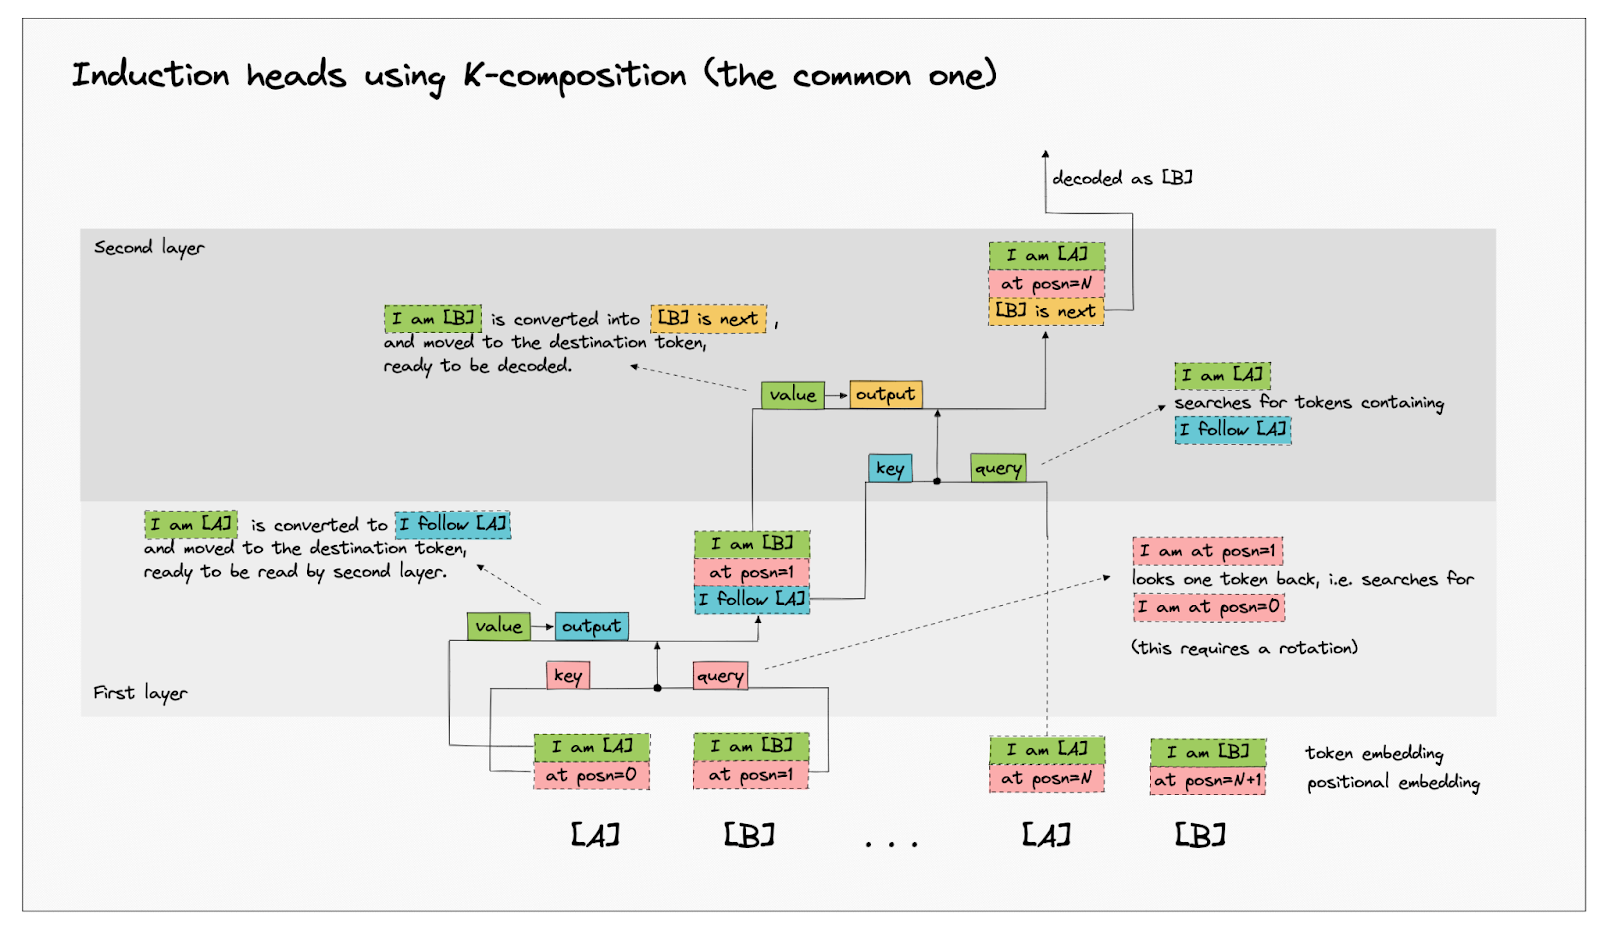